Polynomiar Regression
-->in this use x^0,x^1,x^2 aa rite power maa x ni value levani
y=m0x^0+m1x^1+m2x^2+m3x^3

step1 read csv file
step2 null value find karo
step3 direct x ni direct value naa levaya te karan ti tena power maa convert karyu ---->-2.111^0 = 1  2.111^1= 2.11  2.111^2=4.45 2.111^3=-9.41 
x_train_poly=poly.fit_transform(x_train)
x_train_poly
step5 x and y defined and split into train and test
step6 model banvisu
step7 ane jem value aapi hoy te rite value prdict karvani
step8 MSE find

In [6]:
import pandas as pd
import numpy as np
df=pd.read_csv("Ice_cream selling data.csv")
df.head(5)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


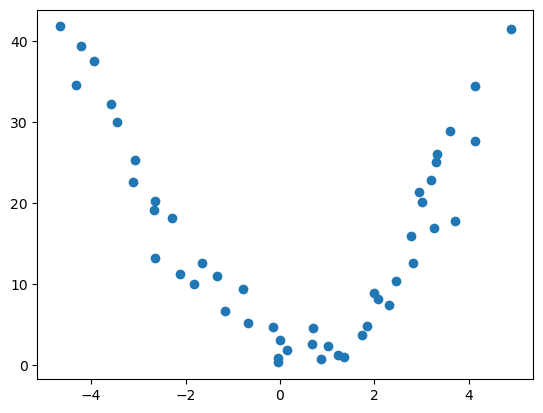

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df["Temperature (°C)"],df["Ice Cream Sales (units)"])
plt.show()

In [13]:
y=df["Ice Cream Sales (units)"]
x=df[["Temperature (°C)"]]

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)#2 dimnesion
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(39, 1)
(10, 1)
(39,)
(10,)


In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
poly
x_train.head(1)

,Temperature (°C)
12,-2.11187


In [24]:
#direct x ni direct value naa levaya te karan ti tena power maa convert karyu ---->-2.111^0 = 1  2.111^1= 2.11  2.111^2=4.45 2.111^3=-9.41 
x_train_poly=poly.fit_transform(x_train)
x_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00,
        -1.86578436e+01],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00,
      

In [30]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
m=lr.coef_
m

array([ 0.        , -1.39956426,  1.87501919,  0.05451597])

In [32]:
c=lr.intercept_
c

np.float64(2.840530985282797)

In [38]:
y1=poly.transform([[10]])#--->degree pramne power return kare same fit_transform jevu che 
y1

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[   1.,   10.,  100., 1000.]])

In [39]:
ice_pre=lr.predict(y1)
ice_pre

array([230.86277446])

In [44]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
x_test_poly=poly.transform(x_test)
y_pred=lr.predict(x_test_poly)#predict kari ne aapiyo answer package 
y_pred=lr.predict(x_test_poly)

print("MSE=",mean_squared_error(y_test,y_pred))
print("MAE=",mean_absolute_error(y_test,y_pred))
print("R2_score",r2_score(y_test,y_pred))

MSE= 15.120009451229496
MAE= 3.22812112977689
R2_score 0.8405107685716914
